<a href="https://colab.research.google.com/github/Prithujit-Ghosh/Student-Performance-Analysis/blob/main/Student_Performance_Dataset_AnalysisFE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Student Performance Dataset Analysis (Feature Engineering Part Only)

**Scenario:** Considering the authority of a college wants to look into the habits, academic performance and socio-economic conditions of its students to predict their grades and identify students who need special attention or at risk of debarment.

**Notebook Structure:**

1. Importing Necessary Libraries

2. Importing The Dataset

3. Data Cleaning and Preprocessing

4. Initial Analysis

5. Data Quality Assessment
6. Distribution Checks, Outlier Detection
7. Encoding Categorical Features
8. Imputation
9. Imputation Success Assessment
10. Feature Creation
11. Outlier Detection within New Features
12. Feature Transformation
13. Correlation Analysis
14. Checking Multicolinearity
15. Selected Features and Insights

**1. Importing Necessary Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**2. Importing The Dataset**

In [ ]:
df_or=pd.read_csv("Students Performance Dataset.csv")

**3. Data Cleaning and Preprocessing**

In [ ]:
#Checking for duplicate in the dataset
print(f"Number of duplicate entries: {df_or.duplicated().sum()}")

Number of duplicate entries: 0


In this case there are no duplicates in the dataset; treatment of duplicates is not required.

**4. Initial Analysis**

In [ ]:
df_or.shape

(5000, 23)

In [ ]:
df_or.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  5000 non-null   object 
 1   First_Name                  5000 non-null   object 
 2   Last_Name                   5000 non-null   object 
 3   Email                       5000 non-null   object 
 4   Gender                      5000 non-null   object 
 5   Age                         5000 non-null   int64  
 6   Department                  5000 non-null   object 
 7   Attendance (%)              5000 non-null   float64
 8   Midterm_Score               5000 non-null   float64
 9   Final_Score                 5000 non-null   float64
 10  Assignments_Avg             5000 non-null   float64
 11  Quizzes_Avg                 5000 non-null   float64
 12  Participation_Score         5000 non-null   float64
 13  Projects_Score              5000 

In [ ]:
df_or.columns

Index(['Student_ID', 'First_Name', 'Last_Name', 'Email', 'Gender', 'Age',
       'Department', 'Attendance (%)', 'Midterm_Score', 'Final_Score',
       'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score',
       'Projects_Score', 'Total_Score', 'Grade', 'Study_Hours_per_Week',
       'Extracurricular_Activities', 'Internet_Access_at_Home',
       'Parent_Education_Level', 'Family_Income_Level', 'Stress_Level (1-10)',
       'Sleep_Hours_per_Night'],
      dtype='object')

In [ ]:
df_or.head()

,Student_ID,First_Name,Last_Name,Email,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,...,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,S1000,Omar,Williams,student0@university.com,Female,22,Mathematics,97.36,40.61,59.61,...,62.84,59.8865,F,10.3,Yes,No,Master's,Medium,1,5.9
1,S1001,Maria,Brown,student1@university.com,Male,18,Business,97.71,57.27,74.00,...,98.23,81.9170,B,27.1,No,No,High School,Low,4,4.3
2,S1002,Ahmed,Jones,student2@university.com,Male,24,Engineering,99.52,41.84,63.85,...,91.22,67.7170,D,12.4,Yes,No,High School,Low,9,6.1
3,S1003,Omar,Williams,student3@university.com,Female,24,Engineering,90.38,45.65,44.44,...,55.48,51.6535,F,25.5,No,Yes,High School,Low,8,4.9
4,S1004,John,Smith,student4@university.com,Female,23,CS,59.41,53.13,61.77,...,87.43,71.4030,C,13.3,Yes,No,Master's,Medium,6,4.5


**Classifying Variables:**

Numerical: 'Age', 'Attendance (%)', 'Midterm_Score', 'Final_Score',
       'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score',
       'Projects_Score', 'Total_Score', 'Study_Hours_per_Week', 'Stress_Level (1-10)', 'Sleep_Hours_per_Night'

Categorical: 'Gender',
       'Department', 'Grade',
       'Extracurricular_Activities', 'Internet_Access_at_Home',
       'Parent_Education_Level', 'Family_Income_Level'

Others: 'Student_ID', 'First_Name', 'Last_Name', 'Email'

Target variable: "Grade"

In [ ]:
#Dropping Redundant Columns
df_or2=df_or.drop(columns=['Student_ID', 'First_Name', 'Last_Name', 'Email','Total_Score'])

In [ ]:
df_or2.head()

,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,Female,22,Mathematics,97.36,40.61,59.61,73.69,53.17,73.4,62.84,F,10.3,Yes,No,Master's,Medium,1,5.9
1,Male,18,Business,97.71,57.27,74.00,74.23,98.23,88.0,98.23,B,27.1,No,No,High School,Low,4,4.3
2,Male,24,Engineering,99.52,41.84,63.85,85.85,50.00,4.7,91.22,D,12.4,Yes,No,High School,Low,9,6.1
3,Female,24,Engineering,90.38,45.65,44.44,68.10,66.27,4.2,55.48,F,25.5,No,Yes,High School,Low,8,4.9
4,Female,23,CS,59.41,53.13,61.77,67.66,83.98,64.3,87.43,C,13.3,Yes,No,Master's,Medium,6,4.5


In [ ]:
df_or2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Gender                      5000 non-null   object 
 1   Age                         5000 non-null   int64  
 2   Department                  5000 non-null   object 
 3   Attendance (%)              5000 non-null   float64
 4   Midterm_Score               5000 non-null   float64
 5   Final_Score                 5000 non-null   float64
 6   Assignments_Avg             5000 non-null   float64
 7   Quizzes_Avg                 5000 non-null   float64
 8   Participation_Score         5000 non-null   float64
 9   Projects_Score              5000 non-null   float64
 10  Grade                       5000 non-null   object 
 11  Study_Hours_per_Week        5000 non-null   float64
 12  Extracurricular_Activities  5000 non-null   object 
 13  Internet_Access_at_Home     5000 

**5. Data Quality Assessment**

In [ ]:
#creating the utility function
def data_quality_check(col):
  return df_or2[col].isnull().sum()/len(df_or2[col])*100

In [ ]:
missing_perc_dict={}
for col in df_or2.columns:
  missing_perc_dict[col]=data_quality_check(col)
print(list(missing_perc_dict.items()))

[('Gender', np.float64(0.0)), ('Age', np.float64(0.0)), ('Department', np.float64(0.0)), ('Attendance (%)', np.float64(0.0)), ('Midterm_Score', np.float64(0.0)), ('Final_Score', np.float64(0.0)), ('Assignments_Avg', np.float64(0.0)), ('Quizzes_Avg', np.float64(0.0)), ('Participation_Score', np.float64(0.0)), ('Projects_Score', np.float64(0.0)), ('Grade', np.float64(0.0)), ('Study_Hours_per_Week', np.float64(0.0)), ('Extracurricular_Activities', np.float64(0.0)), ('Internet_Access_at_Home', np.float64(0.0)), ('Parent_Education_Level', np.float64(20.5)), ('Family_Income_Level', np.float64(0.0)), ('Stress_Level (1-10)', np.float64(0.0)), ('Sleep_Hours_per_Night', np.float64(0.0))]


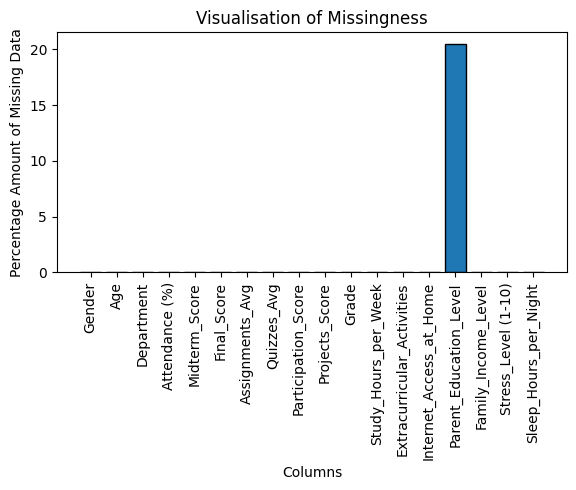

In [ ]:
#Visualisation
# Plot
plt.figure(figsize=(6,5))
plt.bar(missing_perc_dict.keys(), missing_perc_dict.values(), edgecolor="black")
plt.title("Visualisation of Missingness")
plt.ylabel("Percentage Amount of Missing Data")
plt.xlabel("Columns")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Analysis**: The preceding visualisations clearly states that only the column "Parent_Education_Lavel" has missing values.

**6. Distribution Checks, Outlier Detection**

In [ ]:
df_or2.describe(include="all")

,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
count,5000,5000.000000,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000,5000.000000,5000,5000,3975,5000,5000.000000,5000.000000
unique,2,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,NaN,2,2,4,3,NaN,NaN
top,Male,NaN,Engineering,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C,NaN,Yes,Yes,Bachelor's,Low,NaN,NaN
freq,2551,NaN,1274,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2307,NaN,2512,2520,1020,1687,NaN,NaN
mean,NaN,21.048400,NaN,75.356076,70.701924,69.546552,74.956320,74.836214,49.963720,74.78305,NaN,17.521140,NaN,NaN,NaN,NaN,5.507200,6.514420
std,NaN,1.989786,NaN,14.392716,17.436325,17.108996,14.404287,14.423848,28.989785,14.54243,NaN,7.193035,NaN,NaN,NaN,NaN,2.886662,1.446155
min,NaN,18.000000,NaN,50.010000,40.000000,40.010000,50.000000,50.000000,0.000000,50.00000,NaN,5.000000,NaN,NaN,NaN,NaN,1.000000,4.000000
25%,NaN,19.000000,NaN,62.945000,55.707500,54.697500,62.340000,62.357500,25.075000,61.97000,NaN,11.500000,NaN,NaN,NaN,NaN,3.000000,5.300000
50%,NaN,21.000000,NaN,75.670000,70.860000,69.485000,75.090000,74.905000,49.600000,74.54000,NaN,17.400000,NaN,NaN,NaN,NaN,6.000000,6.500000
75%,NaN,23.000000,NaN,87.862500,85.760000,83.922500,87.352500,87.292500,75.500000,87.63000,NaN,23.700000,NaN,NaN,NaN,NaN,8.000000,7.800000


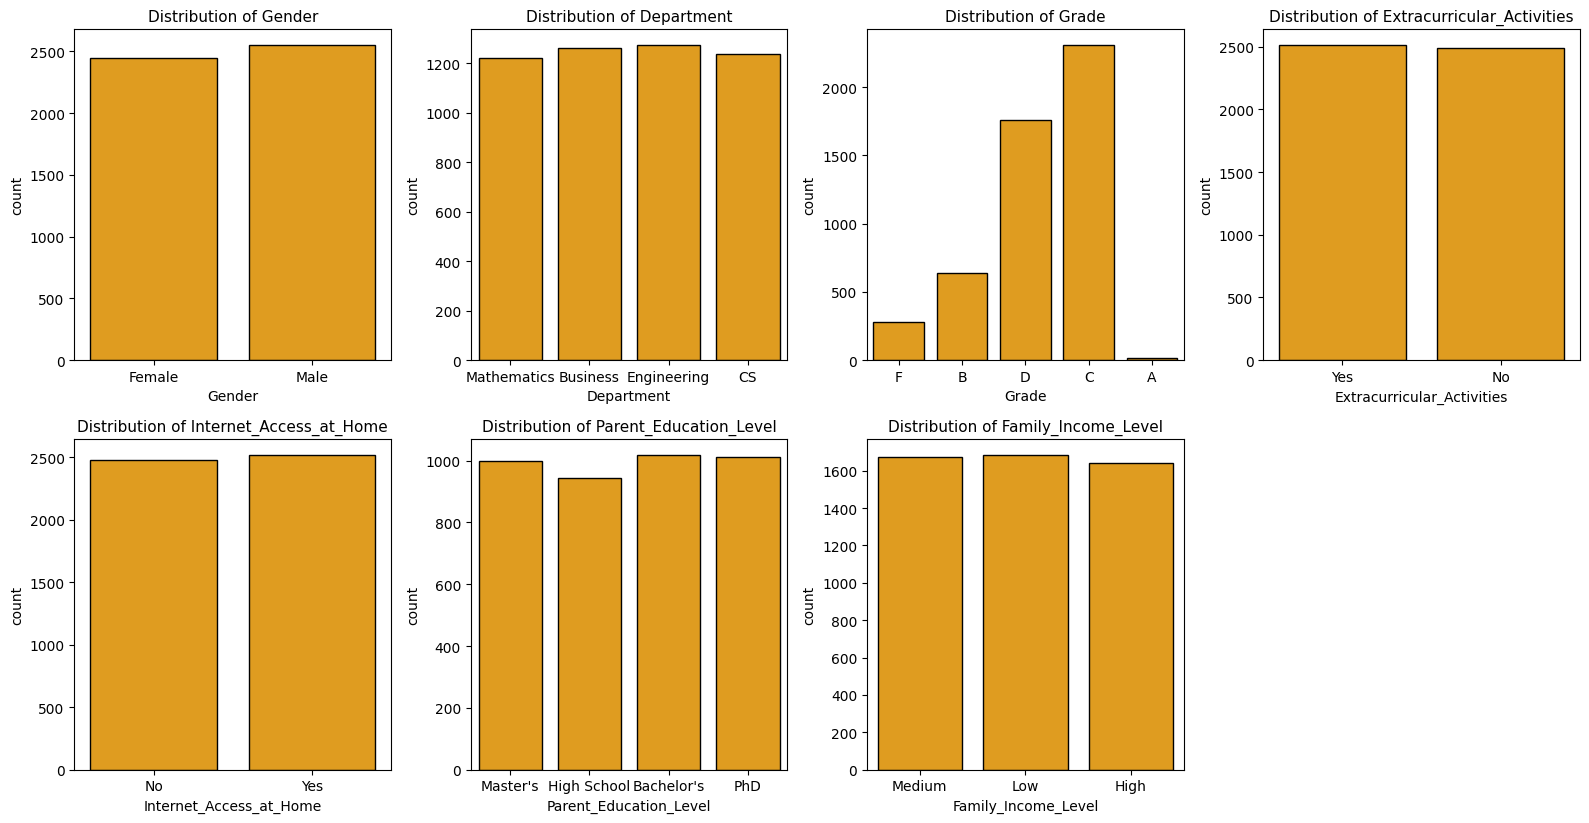

In [ ]:
#Categorical variables
features_to_check = [ 'Gender', 'Department', 'Grade', 'Extracurricular_Activities', 'Internet_Access_at_Home', 'Parent_Education_Level', 'Family_Income_Level']
plt.figure(figsize=(16, 12))

for i, col in enumerate(features_to_check):
    ax = plt.subplot(3, 4, i + 1)  # Create subplot

    # Plot piechart
    sns.countplot(data=df_or2, x=col,ax=ax,color="orange",edgecolor="black")

    # Title for each subplot
    ax.set_title(f'Distribution of {col}', fontsize=11)

# Adjust layout to make space for captions
plt.tight_layout()

plt.show()

**Analysis:** All distributions (except that of Grade) are almost uniform.

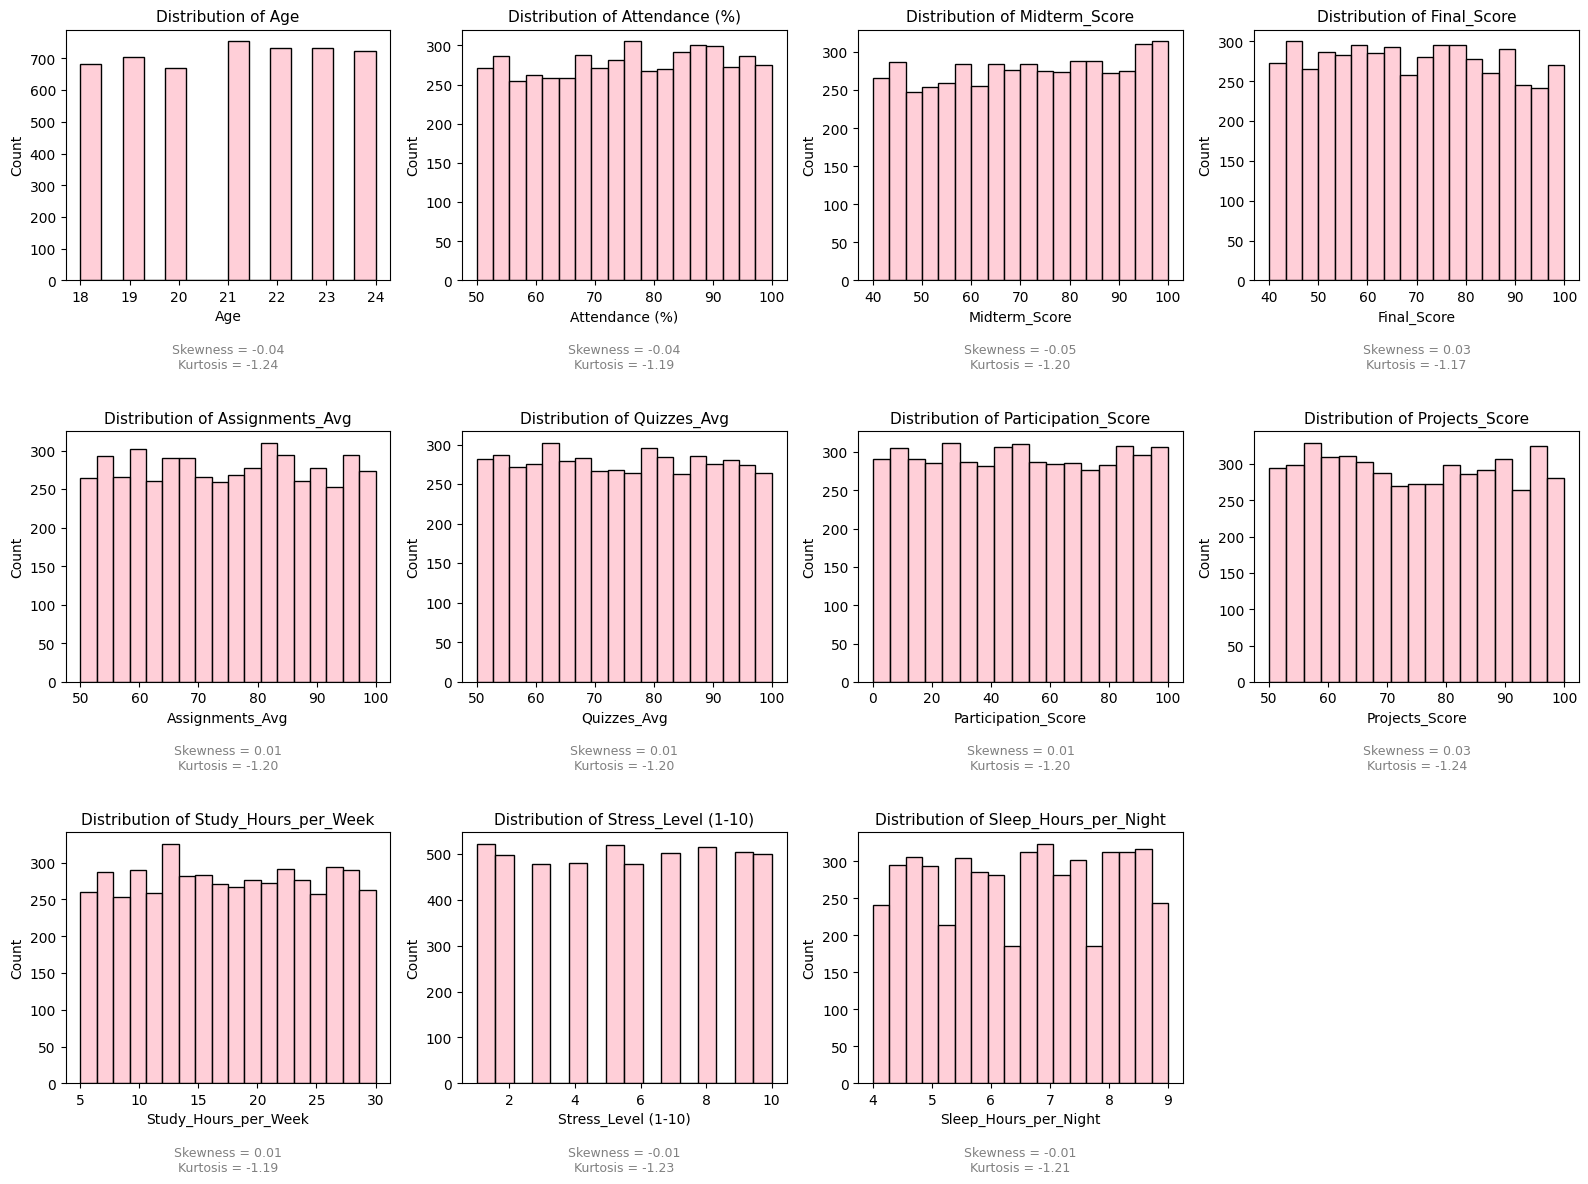

In [ ]:
features_to_check = [
    'Age', 'Attendance (%)', 'Midterm_Score', 'Final_Score',
    'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score',
    'Projects_Score', 'Study_Hours_per_Week', 'Stress_Level (1-10)',
    'Sleep_Hours_per_Night'
]
plt.figure(figsize=(16, 12))

for i, col in enumerate(features_to_check):
    ax = plt.subplot(3, 4, i + 1)  # Create subplot

    # Plot histogram
    sns.histplot(data=df_or2, x=col, color="pink", ax=ax)

    # Calculate skewness & kurtosis
    skew_val = df_or2[col].skew()
    kurt_val = df_or2[col].kurt()

    # Add caption below each subplot
    ax.text(0.5, -0.25, f"Skewness = {skew_val:.2f}\nKurtosis = {kurt_val:.2f}",
            transform=ax.transAxes,
            ha="center", va="top", fontsize=9, color="gray")

    # Title for each subplot
    ax.set_title(f'Distribution of {col}', fontsize=11)

# Adjust layout to make space for captions
plt.tight_layout()
plt.subplots_adjust(hspace=0.6)  # More vertical space

plt.show()

**Analysis:** All distributions are almost uniform with minimal skewness and kurtosis. Hence, no feature transformations are required.

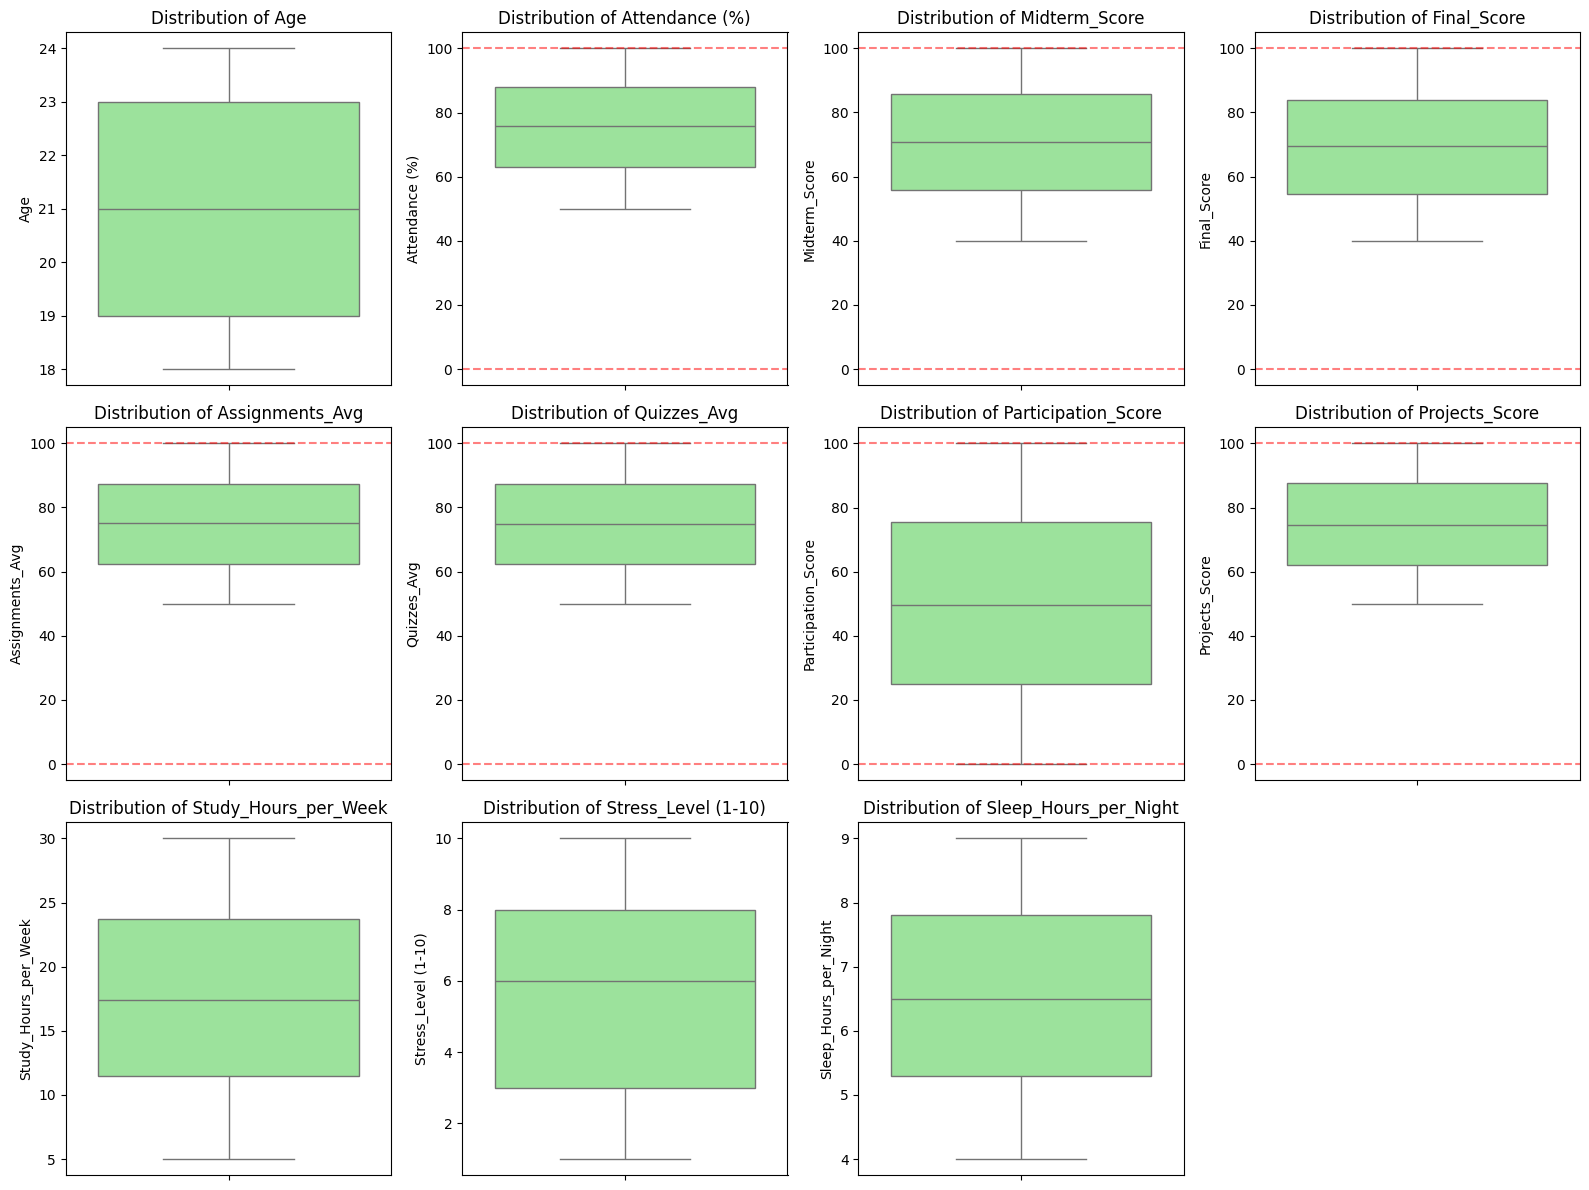

In [ ]:
features_to_check = ['Age', 'Attendance (%)', 'Midterm_Score', 'Final_Score', 'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score', 'Projects_Score', 'Study_Hours_per_Week', 'Stress_Level (1-10)', 'Sleep_Hours_per_Night']

plt.figure(figsize=(16, 12))

for i, col in enumerate(features_to_check):
    plt.subplot(3, 4, i+1)
    sns.boxplot(y=df_or2[col], color="lightgreen")

    # Adding logical limits
    if(col not in ['Study_Hours_per_Week', 'Stress_Level (1-10)', 'Sleep_Hours_per_Night','Age']):
      plt.axhline(0,color="red",alpha=0.5,linestyle='--')
      plt.axhline(100,color="red",alpha=0.5,linestyle='--')

    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

**Analysis:** There are no outliers. Hence, outlier treatment is not required.

**7. Encoding Categorical Features**

In [ ]:
#Using One hot encoding for nominal categorical variable
features_to_one_hot_encode=['Gender', 'Department', 'Extracurricular_Activities', 'Internet_Access_at_Home']
df_ohe=pd.get_dummies(df_or2,columns=features_to_one_hot_encode,drop_first=True,dtype="int16")
print(df_ohe.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             5000 non-null   int64  
 1   Attendance (%)                  5000 non-null   float64
 2   Midterm_Score                   5000 non-null   float64
 3   Final_Score                     5000 non-null   float64
 4   Assignments_Avg                 5000 non-null   float64
 5   Quizzes_Avg                     5000 non-null   float64
 6   Participation_Score             5000 non-null   float64
 7   Projects_Score                  5000 non-null   float64
 8   Grade                           5000 non-null   object 
 9   Study_Hours_per_Week            5000 non-null   float64
 10  Parent_Education_Level          3975 non-null   object 
 11  Family_Income_Level             5000 non-null   object 
 12  Stress_Level (1-10)             50

In [ ]:
#Using Ordinal encodind for ordinal categorical variable
#Initial checking
features_ordinal_encode=[ 'Grade', 'Parent_Education_Level', 'Family_Income_Level']
for i in features_ordinal_encode:
  print(df_ohe[i].unique())

['F' 'B' 'D' 'C' 'A']
["Master's" 'High School' nan "Bachelor's" 'PhD']
['Medium' 'Low' 'High']


In [ ]:
#dictionaries for encoding
Grade_dict={'F':1, 'B':4, 'D':2, 'C':3, 'A':5}
Parent_Education_Level_dict={"Master's":3 ,'High School':1 , "Bachelor's":2, 'PhD':4}
Family_Income_Level_dict={'Medium':2, 'Low':1, 'High':3}
dict_list=[Grade_dict,Parent_Education_Level_dict,Family_Income_Level_dict]

In [ ]:
for index,item in enumerate(features_ordinal_encode):
  df_ohe[f"{item}_enc"]=df_ohe[item].map(dict_list[index])

In [ ]:
df_ohe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             5000 non-null   int64  
 1   Attendance (%)                  5000 non-null   float64
 2   Midterm_Score                   5000 non-null   float64
 3   Final_Score                     5000 non-null   float64
 4   Assignments_Avg                 5000 non-null   float64
 5   Quizzes_Avg                     5000 non-null   float64
 6   Participation_Score             5000 non-null   float64
 7   Projects_Score                  5000 non-null   float64
 8   Grade                           5000 non-null   object 
 9   Study_Hours_per_Week            5000 non-null   float64
 10  Parent_Education_Level          3975 non-null   object 
 11  Family_Income_Level             5000 non-null   object 
 12  Stress_Level (1-10)             50

In [ ]:
df_ohe.head()

,Age,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Grade,Study_Hours_per_Week,...,Sleep_Hours_per_Night,Gender_Male,Department_CS,Department_Engineering,Department_Mathematics,Extracurricular_Activities_Yes,Internet_Access_at_Home_Yes,Grade_enc,Parent_Education_Level_enc,Family_Income_Level_enc
0,22,97.36,40.61,59.61,73.69,53.17,73.4,62.84,F,10.3,...,5.9,0,0,0,1,1,0,1,3.0,2
1,18,97.71,57.27,74.00,74.23,98.23,88.0,98.23,B,27.1,...,4.3,1,0,0,0,0,0,4,1.0,1
2,24,99.52,41.84,63.85,85.85,50.00,4.7,91.22,D,12.4,...,6.1,1,0,1,0,1,0,2,1.0,1
3,24,90.38,45.65,44.44,68.10,66.27,4.2,55.48,F,25.5,...,4.9,0,0,1,0,0,1,1,1.0,1
4,23,59.41,53.13,61.77,67.66,83.98,64.3,87.43,C,13.3,...,4.5,0,1,0,0,1,0,3,3.0,2


In [ ]:
#Dropping original columns
df_un_imputed=df_ohe.copy()
df_un_imputed=df_un_imputed.drop(features_ordinal_encode,axis=1)
print(df_un_imputed.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             5000 non-null   int64  
 1   Attendance (%)                  5000 non-null   float64
 2   Midterm_Score                   5000 non-null   float64
 3   Final_Score                     5000 non-null   float64
 4   Assignments_Avg                 5000 non-null   float64
 5   Quizzes_Avg                     5000 non-null   float64
 6   Participation_Score             5000 non-null   float64
 7   Projects_Score                  5000 non-null   float64
 8   Study_Hours_per_Week            5000 non-null   float64
 9   Stress_Level (1-10)             5000 non-null   int64  
 10  Sleep_Hours_per_Night           5000 non-null   float64
 11  Gender_Male                     5000 non-null   int16  
 12  Department_CS                   50

**8. Imputation**

Since, around 20% of data is missing simple imputation methods (e.g. mode imputation) can potentially distort the underlying distribution.



In [ ]:
#Using Supervised learning approach for imputation

from sklearn.ensemble import RandomForestClassifier

def ordinal_categorical_imputer(df_original, target_col):
  df=df_original.copy()
  #Splitting the dataset
  train_df=df[df[target_col].notnull()]
  predict_df=df[df[target_col].isnull()]
  #Dropping target column
  X_train=train_df.drop(columns=[target_col])
  y_train=train_df[target_col].astype(int)#Eusuring integer labels
  X_predict=predict_df.drop([target_col],axis=1)
  #Initializing and fitting of model
  RFC=RandomForestClassifier(n_estimators=100,class_weight="balanced",random_state=43)
  RFC.fit(X_train,y_train)
  #Imputation
  y_predicted=RFC.predict(X_predict)
  df.loc[df[target_col].isnull(),target_col]=y_predicted

  return df

In [ ]:
df_imputed=ordinal_categorical_imputer(df_un_imputed, "Parent_Education_Level_enc")

In [ ]:
df_imputed.loc[:,"Parent_Education_Level_enc"].head(10)

,Parent_Education_Level_enc
0,3.0
1,1.0
2,1.0
3,1.0
4,3.0
5,4.0
6,2.0
7,3.0
8,4.0
9,2.0


In [ ]:
df_imputed["Parent_Education_Level_enc"].isnull().sum()

np.int64(0)

**9. Imputation Success Assessment**

--- Distribution Comparison ---
                            Before (%)  After (%)
Parent_Education_Level_enc                       
1.0                          23.723270      23.58
2.0                          25.660377      25.88
3.0                          25.157233      25.12
4.0                          25.459119      25.42


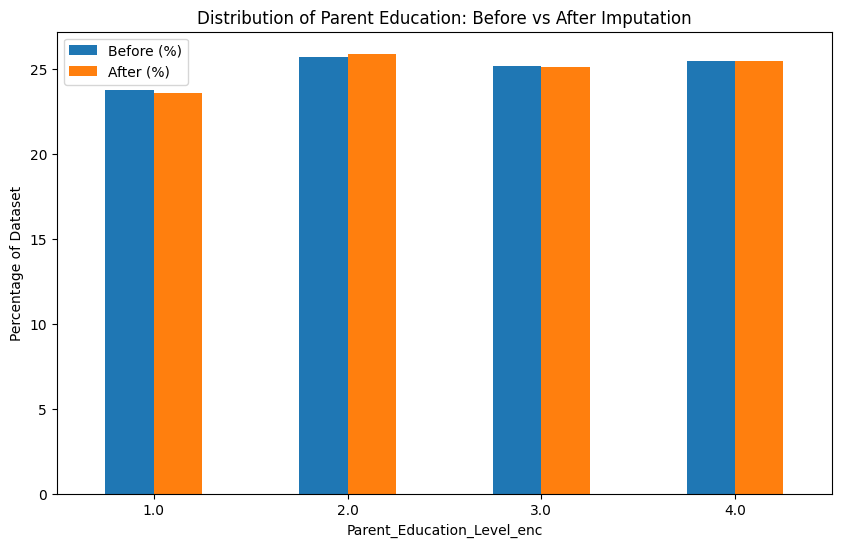

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate distribution BEFORE imputation (as percentages)
dist_before = df_un_imputed['Parent_Education_Level_enc'].value_counts(normalize=True).sort_index()

# 2. Calculate distribution AFTER imputation
dist_after = df_imputed['Parent_Education_Level_enc'].value_counts(normalize=True).sort_index()

# 3. Compare them
comparison_df = pd.DataFrame({
    'Before (%)': dist_before * 100,
    'After (%)': dist_after * 100
})

print("--- Distribution Comparison ---")
print(comparison_df)

# 5. Visualizing the shift
comparison_df.plot(kind='bar', figsize=(10, 6))
plt.title('Distribution of Parent Education: Before vs After Imputation')
plt.ylabel('Percentage of Dataset')
plt.xticks(rotation=0)
plt.show()

**Analysis**: The visualisation clearly shows that the respective classes under "Parent_Education_Level_enc" are almost similar before and after imputation. Therefore, the imputation can be considerd successful.

**10. Feature Creation**

In [ ]:
#1. Creating feature: "Academic_Efficiency"
df_imputed["Academic_Efficiency"]=df_imputed['Midterm_Score']/df_imputed["Study_Hours_per_Week"]
#2. Creating feature: "Burnout_Index"
df_imputed["Burnout_Index"]=df_imputed['Stress_Level (1-10)']/df_imputed['Sleep_Hours_per_Night']
#3. Creating feature :"Low_Attendance"; to identify students at risk of debarment
df_imputed["Low_Attendance"]=df_imputed["Attendance (%)"].apply(lambda x: 1 if (x>=75) else 0)
#4. Creating feature:Inconsistency_Score
df_imputed['Inconsistency_Score']=df_imputed[['Midterm_Score',
       'Assignments_Avg', 'Quizzes_Avg',"Participation_Score",
       'Projects_Score']].std(axis=1,ddof=0)

**11. Outlier Detection within New Features**

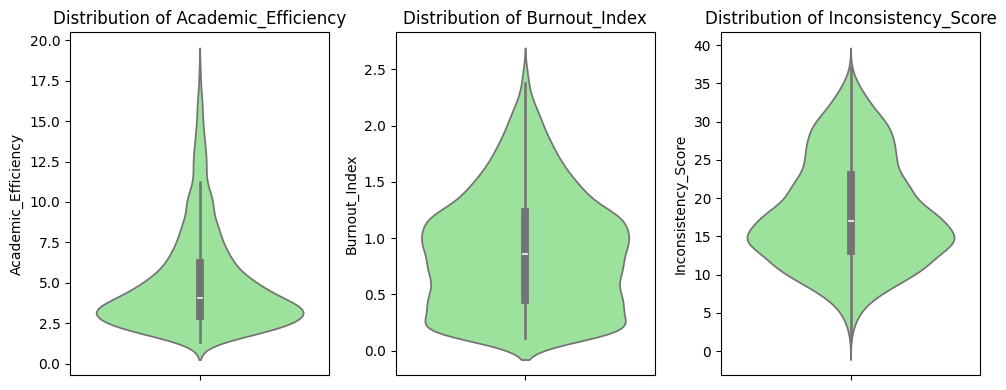

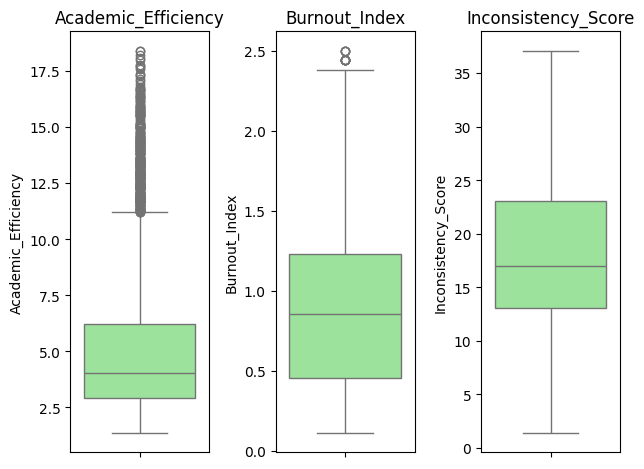

In [ ]:
features_to_check = ["Academic_Efficiency" ,"Burnout_Index", 'Inconsistency_Score']

plt.figure(figsize=(10,4))

for i, col in enumerate(features_to_check):
    plt.subplot(1, 3, i+1)
    sns.violinplot(y=df_imputed[col], color="lightgreen", inner="box")
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()
for i, col in enumerate(features_to_check):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df_imputed[col], color="lightgreen")
    plt.title(col)
plt.tight_layout()
plt.show()

**Analysis**:There are outliers present at the top of the distribution of "Academic_Efficiency" at a noticeable amount and a few outliers can be observed in the distribution of "Burnout_Index" in same direction.

**12. Feature Transformation**

In [ ]:
#Using log transformation
#Using log1p (log(1+x)) to avoid errors (due to log(0))
df_imputed['Academic_Efficiency_log']=np.log1p(df_imputed['Academic_Efficiency'])
df_imputed['Burnout_Index_log']=np.log1p(df_imputed['Burnout_Index'])

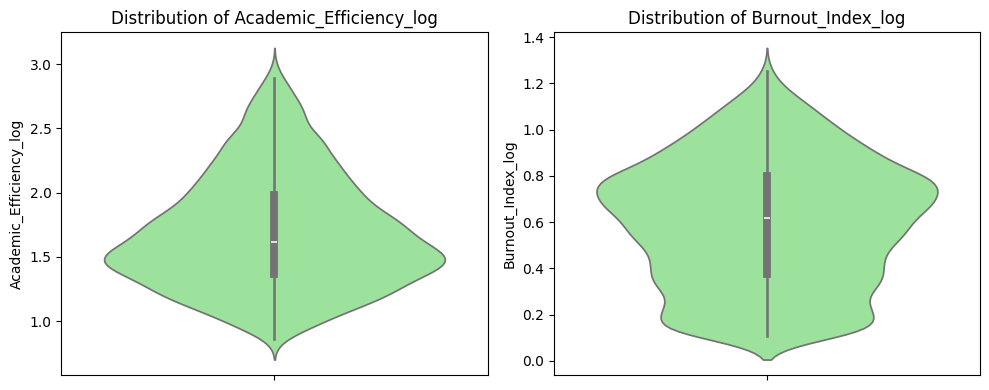

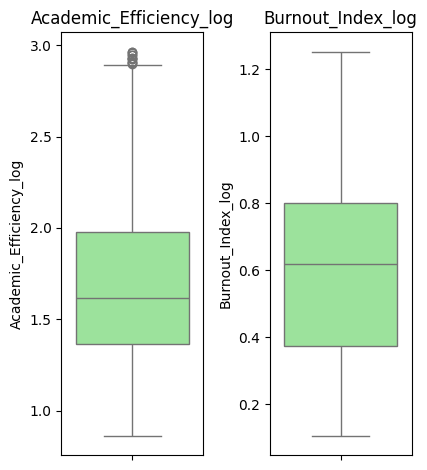

In [ ]:
features_to_check = ["Academic_Efficiency_log" , 'Burnout_Index_log']
plt.figure(figsize=(10,4))
for i, col in enumerate(features_to_check):
    plt.subplot(1, 2, i+1)
    sns.violinplot(y=df_imputed[col], color="lightgreen", inner="box")
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()
for i, col in enumerate(features_to_check):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df_imputed[col], color="lightgreen")
    plt.title(col)
plt.tight_layout()
plt.show()

**Analysis**: Log transformation has significantly reduced the number of outliers in "Academic_Efficiency". But there are still some outliers (extreme outliers) left.

In [ ]:
#Using winsorization (clipping)
Q3=df_imputed["Academic_Efficiency_log"].quantile(0.75)
Q1=df_imputed["Academic_Efficiency_log"].quantile(0.25)
IQR=Q3-Q1
upper_bound=Q3+1.5*IQR
df_imputed["Academic_Efficiency_log"]=df_imputed['Academic_Efficiency_log'].clip(upper=upper_bound)

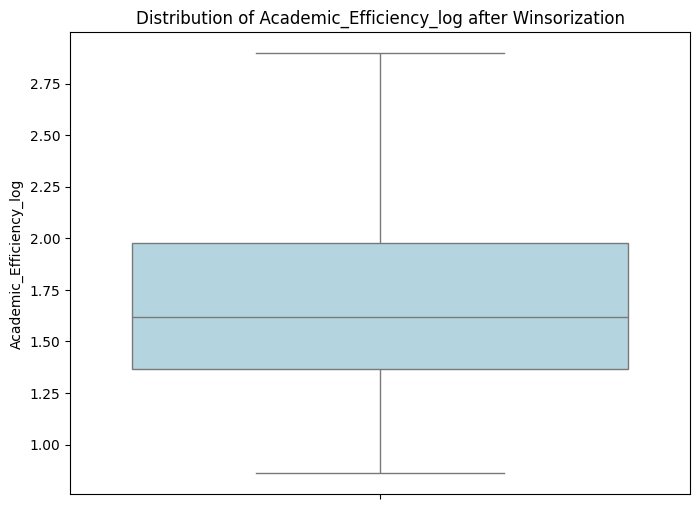

In [ ]:
#visualisation
plt.figure(figsize=(8,6))
sns.boxplot(y=df_imputed["Academic_Efficiency_log"], color="lightblue")
plt.title("Distribution of Academic_Efficiency_log after Winsorization")
plt.show()

In [ ]:
#Dropping redundant columns
df_imputed=df_imputed.drop(["Academic_Efficiency" ,"Burnout_Index"],axis=1)

**13. Correlation Analysis**

In [ ]:
#Dropping columns that are highly correlated with "Grade_enc" and/or may not be available at the time of prediction
#to prevent target leakage
#Example: if the model is to be used to identify students at risk before there final exams
df_imputed_reduced=df_imputed.drop(columns=['Final_Score'])#These feature(s) are usually calculated at the end of the semester

In [ ]:
#Checking correlation with 'Midterm_Score' to look for very high correlation
#as it may make the model overly dependent on a single feature
df_imputed_reduced.loc[:,['Midterm_Score','Assignments_Avg', 'Quizzes_Avg', 'Participation_Score',
       'Projects_Score',"Grade_enc"]].corr()

,Midterm_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Grade_enc
Midterm_Score,1.000000,-0.025153,-0.013974,-0.017434,-0.024138,0.307355
Assignments_Avg,-0.025153,1.000000,0.000662,0.019216,0.024666,0.301702
Quizzes_Avg,-0.013974,0.000662,1.000000,0.013216,0.002909,0.187974
Participation_Score,-0.017434,0.019216,0.013216,1.000000,-0.013334,0.181873
Projects_Score,-0.024138,0.024666,0.002909,-0.013334,1.000000,0.547604
Grade_enc,0.307355,0.301702,0.187974,0.181873,0.547604,1.000000


**Conclusion:** No signficantly high correlation (with grade) was observed, there is no risk of target leakage.

In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import StandardScaler
# Using SelectKBest (f_regression) - for regression tasks
#Scaling the data
df_un_std=df_imputed_reduced.drop("Grade_enc",axis=1)
scalar=StandardScaler()
scalar.fit(df_un_std)
X_scaled=scalar.transform(df_un_std)
#target feature
y=df_imputed_reduced["Grade_enc"]

In [ ]:
#Select top K features
selector=SelectKBest(score_func=f_regression,k=int(input("Enter no. of features to select(<19):")))

Enter no. of features to select(<19):6


In [ ]:
X_new=selector.fit_transform(X_scaled,y)

In [ ]:
#Obtaining the indices of the selected features
list_col=df_un_std.columns[selector.get_support()]
print(list_col)

Index(['Midterm_Score', 'Assignments_Avg', 'Quizzes_Avg',
       'Participation_Score', 'Projects_Score', 'Academic_Efficiency_log'],
      dtype='object')


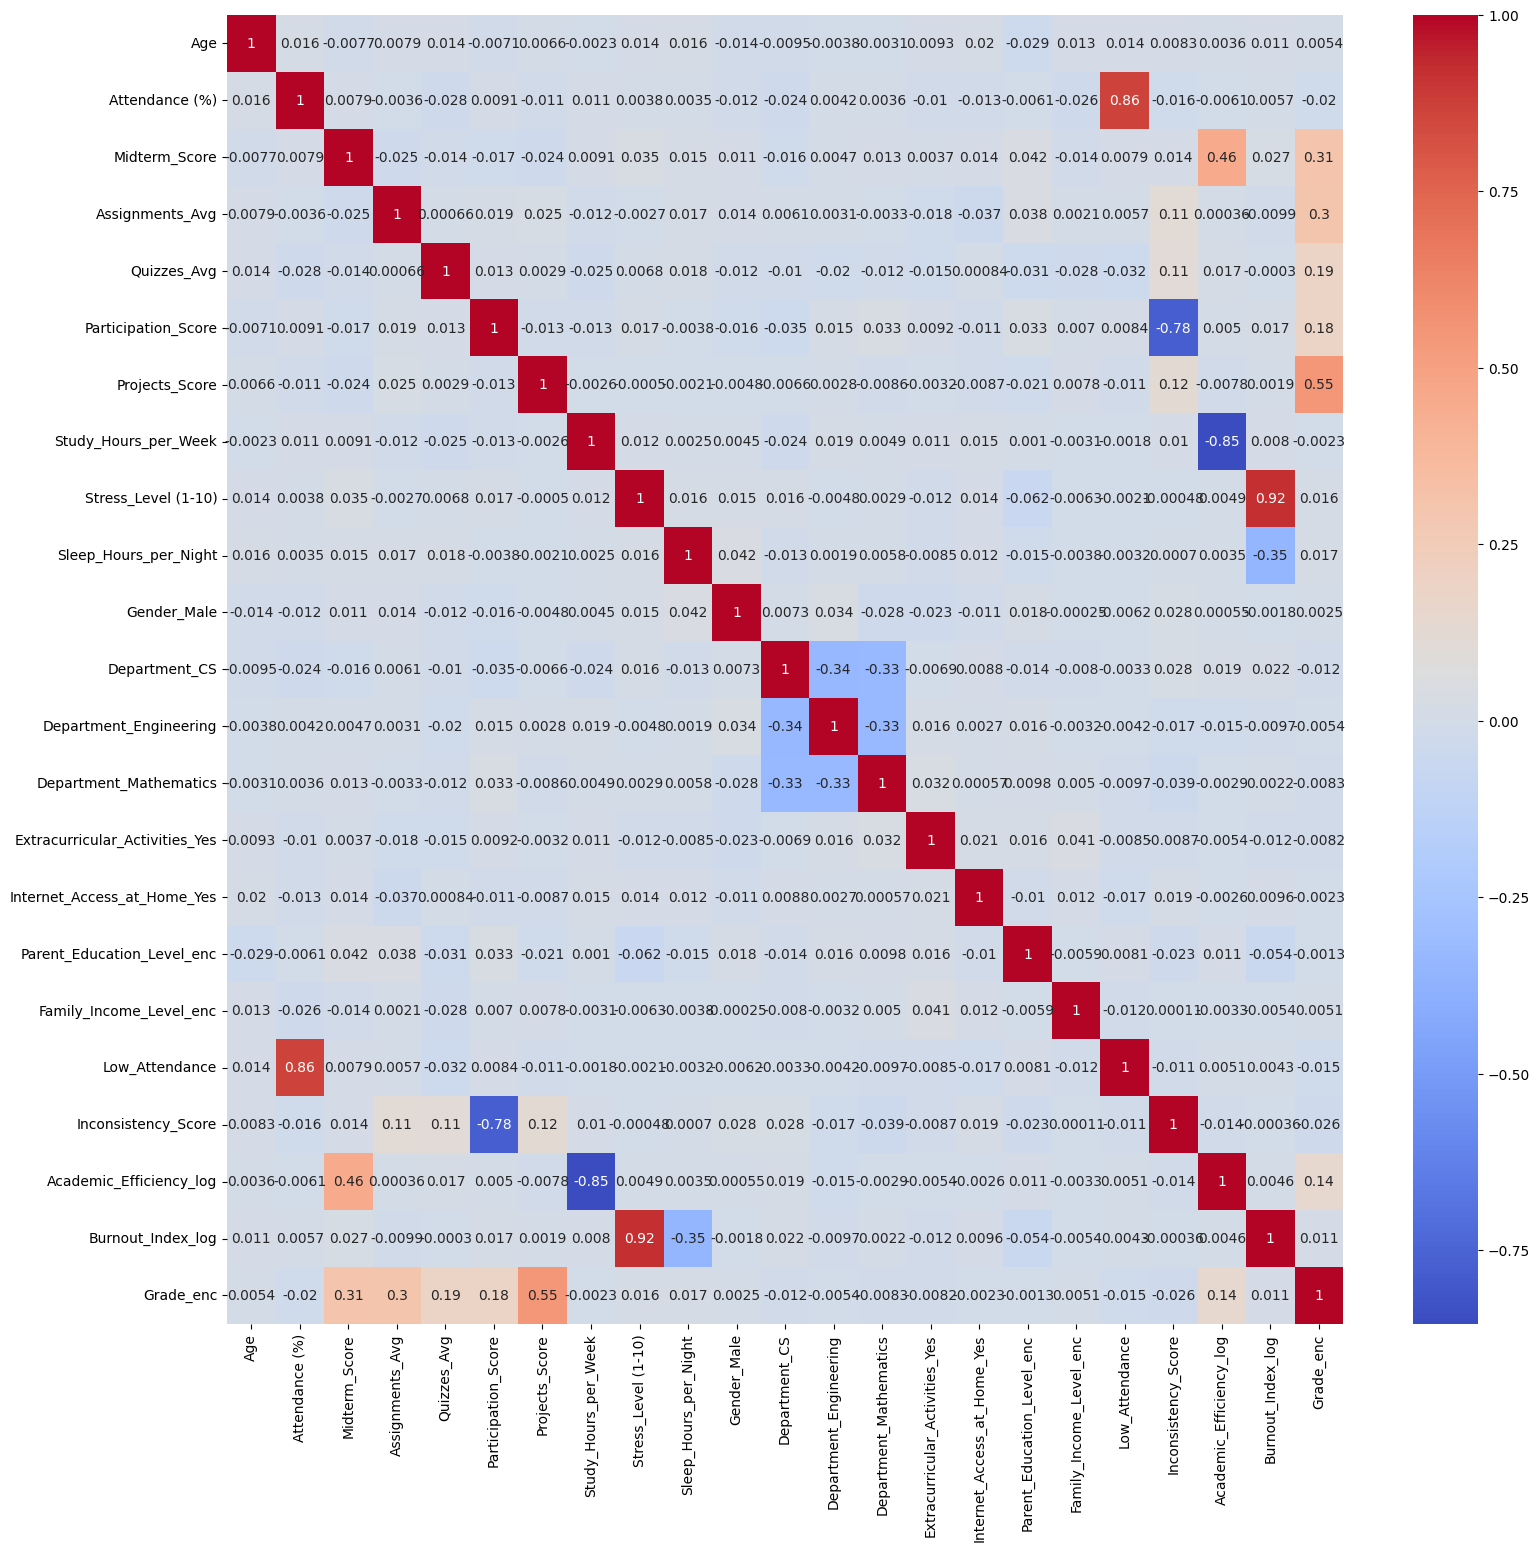

In [ ]:
#Rebuilding the dataframe
df_scaled=pd.DataFrame(X_scaled,columns=df_un_std.columns)
df_scaled["Grade_enc"]=df_imputed_reduced["Grade_enc"]
# Visualizing with heatmap
plt.figure(figsize=(18,17))
sns.heatmap(df_scaled.corr(), annot=True, cmap='coolwarm')
plt.show()

**Analysis:** Visual inspection confirms that 'Midterm_Score', 'Assignments_Avg', 'Quizzes_Avg','Participation_Score', 'Projects_Score', 'Academic_Efficiency_log' have strongest correlations with grades. This observation perfectly aligns with the result of SelectKBest().

**14. Checking Multicolinearity**

In [ ]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def calculate_vif(df, features):
    # VIF requires a constant (intercept) to be added to the data
    X = df[features].copy()
    X = add_constant(X)

    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns

    # Calculate VIF for each feature
    vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                       for i in range(len(X.columns))]

    # Dropping the 'const' row as we don't need it for interpretation
    return vif_data[vif_data['feature'] != 'const'].sort_values('VIF', ascending=False)

#Using
features_to_check = [
    'Midterm_Score', 'Assignments_Avg', 'Quizzes_Avg',
       'Participation_Score', 'Projects_Score', 'Academic_Efficiency_log',
       'Inconsistency_Score',"Burnout_Index_log","Low_Attendance",
]

vif_results = calculate_vif(df_scaled, features_to_check)
print(vif_results)

                   feature       VIF
7      Inconsistency_Score  2.843266
4      Participation_Score  2.740173
1            Midterm_Score  1.266235
6  Academic_Efficiency_log  1.263910
2          Assignments_Avg  1.044129
3              Quizzes_Avg  1.041097
5           Projects_Score  1.032690
8        Burnout_Index_log  1.001741
9           Low_Attendance  1.001331


**Analysis:** We know, generally VIF score of less than 5 is safe.

Hence, if a model trained on this data, it can distinguish the effects of each feature individually.

**15. Selected Features and Insights**

Features with strong correlations are:

'Midterm_Score', 'Assignments_Avg', 'Quizzes_Avg',
'Participation_Score', 'Projects_Score', 'Academic_Efficiency_log'

Feature needed for checking minimum attendance criteria:'Low_Attendance'


**Insights**:
*   No significant impact of socio-economic factors: Factors like parent education and income has little to  almost no influence on academic success. This suggests that with sufficient and appropriate guidance and support from college can ensure academic success irrespective of socio-economic factors.
*   Dominance of academic factors: Academic factors are the primary drivers of grades.

*   Profound dominance of "Projects_Score": This can be explained by two factors:
1. Calculation of total scores gives project scores higher weightage.
2. Individuals with good project building skills also tend to have high scoring ability.

*   Department independant: Students' performances are almost uniform across all departments.